In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load JST
jst = pd.read_stata('../data/raw/JSTdatasetR6.dta')

print("Shape:", jst.shape)
print("Years:", jst['year'].min(), "to", jst['year'].max())
print("Countries:", sorted(jst['iso'].unique()))

Shape: (2718, 59)
Years: 1870 to 2020
Countries: ['AUS', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'IRL', 'ITA', 'JPN', 'NLD', 'NOR', 'PRT', 'SWE', 'USA']


In [2]:
print("Crisis label distribution:")
print(jst['crisisJST'].value_counts())
print(f"\nCrisis rate: {jst['crisisJST'].mean():.1%}")

Crisis label distribution:
crisisJST
0.0    2580
1.0      88
Name: count, dtype: int64

Crisis rate: 3.3%


In [3]:
print(jst.columns)


Index(['year', 'country', 'iso', 'ifs', 'pop', 'rgdpmad', 'rgdpbarro',
       'rconsbarro', 'gdp', 'iy', 'cpi', 'ca', 'imports', 'exports', 'narrowm',
       'money', 'stir', 'ltrate', 'hpnom', 'unemp', 'wage', 'debtgdp',
       'revenue', 'expenditure', 'xrusd', 'tloans', 'tmort', 'thh', 'tbus',
       'bdebt', 'lev', 'ltd', 'noncore', 'crisisJST', 'crisisJST_old', 'peg',
       'peg_strict', 'peg_type', 'peg_base', 'JSTtrilemmaIV', 'eq_tr',
       'housing_tr', 'bond_tr', 'bill_rate', 'rent_ipolated',
       'housing_capgain_ipolated', 'housing_capgain', 'housing_rent_rtn',
       'housing_rent_yd', 'eq_capgain', 'eq_dp', 'eq_capgain_interp',
       'eq_tr_interp', 'eq_dp_interp', 'bond_rate', 'eq_div_rtn', 'capital_tr',
       'risky_tr', 'safe_tr'],
      dtype='str')


In [4]:
label_col = "crisisJST"   # or "crisisJST_old"

print("Crisis label distribution:")
print(jst[label_col].value_counts(dropna=False))

print(f"\nCrisis rate: {jst[label_col].mean():.1%}")


Crisis label distribution:
crisisJST
0.0    2580
1.0      88
NaN      50
Name: count, dtype: int64

Crisis rate: 3.3%


In [5]:
print("Crisis label distribution:")
print(jst["crisisJST"].value_counts())
print(f"\nCrisis rate: {jst['crisisJST'].mean():.1%}")

Crisis label distribution:
crisisJST
0.0    2580
1.0      88
Name: count, dtype: int64

Crisis rate: 3.3%


In [7]:
key_vars = ['year','iso','crisisJST','tloans_gdp','drate','hpnom','eq_tr','ca_gdp']
missing = [c for c in key_vars if c not in jst.columns]
print("Missing columns:", missing)

present = [c for c in key_vars if c in jst.columns]
print(jst[present].describe(include="all"))


Missing columns: ['tloans_gdp', 'drate', 'ca_gdp']
              year   iso    crisisJST         hpnom         eq_tr
count   2718.00000  2718  2668.000000  2.050000e+03  2.263000e+03
unique         NaN    18          NaN           NaN           NaN
top            NaN   AUS          NaN           NaN           NaN
freq           NaN   151          NaN           NaN           NaN
mean    1945.00000   NaN     0.032984  6.701077e+01  1.166184e+06
std       43.59701   NaN     0.178627  1.061261e+02  5.547655e+07
min     1870.00000   NaN     0.000000  3.014026e-12 -8.841469e-01
25%     1907.00000   NaN     0.000000  2.423478e+00 -1.370092e-02
50%     1945.00000   NaN     0.000000  1.027627e+01  8.600000e-02
75%     1983.00000   NaN     0.000000  9.785925e+01  1.981390e-01
max     2020.00000   NaN     1.000000  6.459109e+02  2.639075e+09


In [8]:
# Create derived variables that don't exist yet
jst = jst.copy()

jst["tloans_gdp"] = jst["tloans"] / jst["gdp"]
jst["ca_gdp"]     = jst["ca"] / jst["gdp"]

# Define drate (choose one of these; default = short-term interest rate)
jst["drate"] = jst["stir"]          # alternative: jst["bill_rate"] or jst["ltrate"] or jst["bond_rate"]

# Now describe key variables
key_vars = ["year", "iso", "crisisJST", "tloans_gdp", "drate", "hpnom", "eq_tr", "ca_gdp"]
print(jst[key_vars].describe(include="all"))


              year   iso    crisisJST   tloans_gdp        drate         hpnom  \
count   2718.00000  2718  2668.000000  2445.000000  2520.000000  2.050000e+03   
unique         NaN    18          NaN          NaN          NaN           NaN   
top            NaN   AUS          NaN          NaN          NaN           NaN   
freq           NaN   151          NaN          NaN          NaN           NaN   
mean    1945.00000   NaN     0.032984     0.586242     4.677768  6.701077e+01   
std       43.59701   NaN     0.178627     0.361725     3.332995  1.061261e+02   
min     1870.00000   NaN     0.000000     0.004682    -2.000000  3.014026e-12   
25%     1907.00000   NaN     0.000000     0.307626     2.627500  2.423478e+00   
50%     1945.00000   NaN     0.000000     0.528971     4.122500  1.027627e+01   
75%     1983.00000   NaN     0.000000     0.799413     5.758750  9.785925e+01   
max     2020.00000   NaN     1.000000     2.035726    21.273300  6.459109e+02   

               eq_tr       

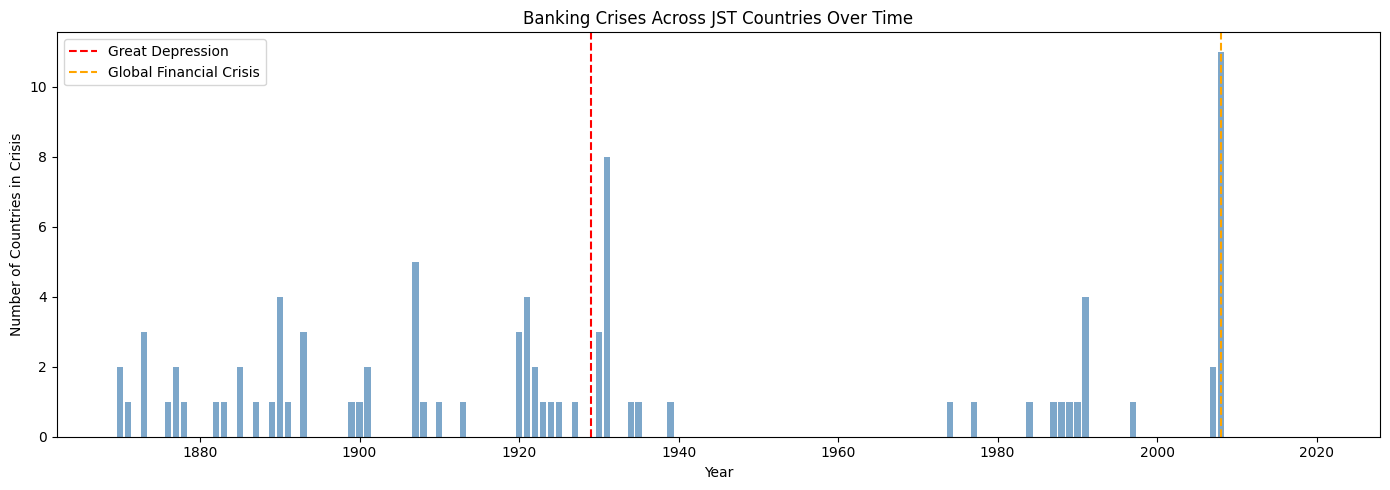

In [9]:
import matplotlib.pyplot as plt

# Sum of crisis indicators across countries each year
crises_by_year = (
    jst.groupby("year")["crisisJST"]
      .sum(min_count=1)   # keeps NaN if an entire year is missing (rare), otherwise sums
)

plt.figure(figsize=(14, 5))
plt.bar(crises_by_year.index, crises_by_year.values, color="steelblue", alpha=0.7)

plt.axvline(1929, color="red", linestyle="--", label="Great Depression")
plt.axvline(2008, color="orange", linestyle="--", label="Global Financial Crisis")

plt.xlabel("Year")
plt.ylabel("Number of Countries in Crisis")
plt.title("Banking Crises Across JST Countries Over Time")
plt.legend()
plt.tight_layout()

plt.savefig("../outputs/01_crisis_frequency.png", dpi=150)
plt.show()
